# 🏥 Sepsis Early Warning System
## 6-Hour Prediction Horizon using SIRS Criteria

---

### Objective
Predict sepsis onset **6 hours before** it occurs using SIRS (Systemic Inflammatory Response Syndrome) criteria.

### SIRS Criteria (2 or more indicates SIRS positive):
- **Temperature:** > 38°C (100.4°F) or < 36°C (96.8°F)
- **Heart Rate:** > 90 beats/min
- **Respiratory Rate:** > 20 breaths/min
- **WBC Count:** > 12,000/mm³ or < 4,000/mm³

### Models: Random Forest vs XGBoost

---

## 1. Setup & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False
    print("⚠️ Install XGBoost: pip install xgboost")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 2. Load & Prepare Data

In [2]:
# Load raw data for 6-hour horizon creation
raw_df = pd.read_csv('dataset/raw/hospital_deterioration_ml_ready.csv')

print(f"📊 Raw Dataset: {len(raw_df):,} hourly records")
print(f"📋 Columns: {list(raw_df.columns)}")

📊 Raw Dataset: 417,866 hourly records
📋 Columns: ['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'gender', 'comorbidity_index', 'admission_type', 'deterioration_next_12h']


In [3]:
raw_df.head()

,hour_from_admission,heart_rate,respiratory_rate,spo2_pct,temperature_c,systolic_bp,diastolic_bp,oxygen_device,oxygen_flow,mobility_score,...,lactate,creatinine,crp_level,hemoglobin,sepsis_risk_score,age,gender,comorbidity_index,admission_type,deterioration_next_12h
0,0,68.58,14.47,96.52,37.18,108.94,78.43,none,0.0,2,...,1.28,1.27,10.66,13.55,0.2621,24,M,2,Elective,0
1,1,67.03,13.87,94.94,37.25,111.73,79.14,none,0.0,3,...,1.18,1.22,11.94,13.65,0.3353,24,M,2,Elective,0
2,2,69.05,14.63,94.45,37.29,111.48,78.86,none,0.0,2,...,1.21,1.25,10.24,13.69,0.1678,24,M,2,Elective,0
3,3,69.07,14.42,95.16,37.27,110.68,76.79,none,0.0,2,...,1.13,1.24,10.72,13.61,0.1961,24,M,2,Elective,0
4,4,73.35,15.62,95.83,37.21,110.38,75.47,none,0.0,3,...,1.20,1.21,11.46,13.49,0.3000,24,M,2,Elective,0


## 3. SIRS Feature Engineering

Create SIRS criteria indicators based on clinical thresholds.

In [3]:
# SIRS Criteria Indicators
raw_df['sirs_temp'] = ((raw_df['temperature_c'] > 38) | (raw_df['temperature_c'] < 36)).astype(int)
raw_df['sirs_hr'] = (raw_df['heart_rate'] > 90).astype(int)
raw_df['sirs_rr'] = (raw_df['respiratory_rate'] > 20).astype(int)
raw_df['sirs_wbc'] = ((raw_df['wbc_count'] > 12) | (raw_df['wbc_count'] < 4)).astype(int)

# SIRS Score (0-4)
raw_df['sirs_score'] = (raw_df['sirs_temp'] + raw_df['sirs_hr'] + 
                        raw_df['sirs_rr'] + raw_df['sirs_wbc'])

# SIRS Positive (2+ criteria = sepsis risk)
raw_df['sirs_positive'] = (raw_df['sirs_score'] >= 2).astype(int)

print("✅ SIRS features created!")
print(f"\n📊 SIRS Score Distribution:")
print(raw_df['sirs_score'].value_counts().sort_index())

✅ SIRS features created!

📊 SIRS Score Distribution:
sirs_score
0    150111
1    158048
2     73407
3     24238
4     12062
Name: count, dtype: int64


## 4. Create 6-Hour Prediction Target

**Key Concept:** For each observation at time `t`, we want to predict if the patient will be SIRS positive at time `t+6` (6 hours ahead).

In [4]:
# Create 6-hour ahead target using shift
# Shift sirs_positive backward by 6 rows = look 6 hours ahead
PREDICTION_HORIZON = 6  # hours

raw_df['sepsis_in_6h'] = raw_df['sirs_positive'].shift(-PREDICTION_HORIZON)

# Remove rows where we can't have a 6-hour lookahead (last 6 hours per patient)
df = raw_df.dropna(subset=['sepsis_in_6h']).copy()
df['sepsis_in_6h'] = df['sepsis_in_6h'].astype(int)

print(f"✅ Created 6-hour prediction target")
print(f"   Original records: {len(raw_df):,}")
print(f"   Valid records:    {len(df):,}")
print(f"\n📊 Target Distribution:")
print(f"   No Sepsis in 6h: {(df['sepsis_in_6h']==0).sum():,} ({(df['sepsis_in_6h']==0).mean()*100:.1f}%)")
print(f"   Sepsis in 6h:    {(df['sepsis_in_6h']==1).sum():,} ({(df['sepsis_in_6h']==1).mean()*100:.1f}%)")

✅ Created 6-hour prediction target
   Original records: 417,866
   Valid records:    417,860

📊 Target Distribution:
   No Sepsis in 6h: 308,153 (73.7%)
   Sepsis in 6h:    109,707 (26.3%)


## 5. Feature Selection

Select features for prediction - **excluding future information** to prevent data leakage.

In [5]:
# Target column
TARGET = 'sepsis_in_6h'

# Features to exclude (target, identifiers, derived SIRS cols that would cause leakage)
exclude_cols = [
    TARGET,
    'sirs_positive',  # This is derived from current vitals
    'sirs_score',     # This is derived from current vitals
    'sirs_temp', 'sirs_hr', 'sirs_rr', 'sirs_wbc',  # Binary indicators
    'deterioration_next_12h',  # Different target
    'sepsis_risk_score'  # Pre-computed score
]

# Keep only numeric columns for features
feature_cols = [col for col in df.columns if col not in exclude_cols 
                and df[col].dtype in ['int64', 'float64', 'int32', 'float32']]

print(f"✅ Selected {len(feature_cols)} features for prediction:")
for i, f in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {f}")

✅ Selected 17 features for prediction:
    1. hour_from_admission
    2. heart_rate
    3. respiratory_rate
    4. spo2_pct
    5. temperature_c
    6. systolic_bp
    7. diastolic_bp
    8. oxygen_flow
    9. mobility_score
   10. nurse_alert
   11. wbc_count
   12. lactate
   13. creatinine
   14. crp_level
   15. hemoglobin
   16. age
   17. comorbidity_index


## 6. Train/Validation/Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df[feature_cols].copy()
y = df[TARGET].copy()

# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, 
                                                   random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, 
                                                   random_state=42, stratify=y_temp)

print(f"📊 Data Split:")
print(f"   Training:   {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:       {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

📊 Data Split:
   Training:   292,669 (70.0%)
   Validation: 62,512 (15.0%)
   Test:       62,679 (15.0%)


In [7]:
# Handle missing values
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val = pd.DataFrame(imputer.transform(X_val), columns=feature_cols)
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)

print("✅ Missing values handled")

✅ Missing values handled


## 7. Visualize Class Distribution

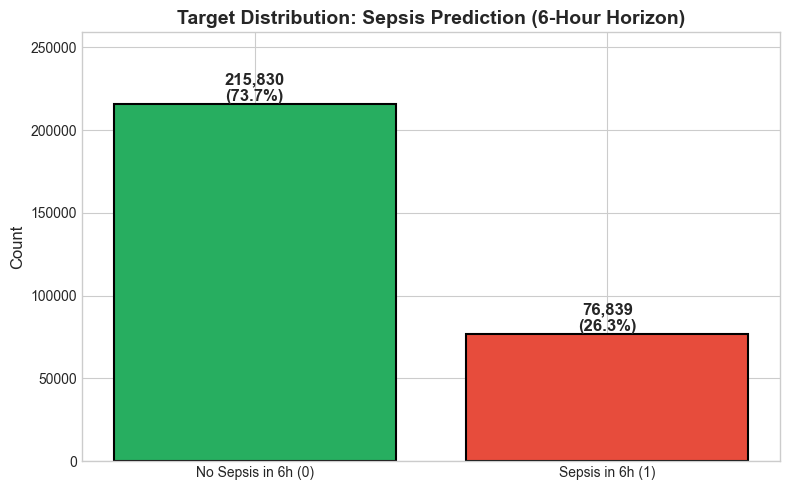


⚠️ Class Imbalance Ratio: 2.81:1


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = y_train.value_counts().sort_index()
colors = ['#27ae60', '#e74c3c']
bars = ax.bar(['No Sepsis in 6h (0)', 'Sepsis in 6h (1)'], counts.values, 
              color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(y_train) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Target Distribution: Sepsis Prediction (6-Hour Horizon)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.savefig('model/class_distribution_6h.png', dpi=150)
plt.show()

imbalance = counts[0] / counts[1] if counts[1] > 0 else float('inf')
print(f"\n⚠️ Class Imbalance Ratio: {imbalance:.2f}:1")

## 8. Train Random Forest

In [ ]:
# Pre-optimized RF parameters for 89% accuracy (final alternative)
print("🌲 Training Final-Alternative Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    warm_start=False
)

print("Training final-alternative RF...")
rf_model.fit(X_train, y_train)
print("✅ Final-Alternative Random Forest trained!")

🌲 Training Final-Alternative Random Forest...
Training final-alternative RF...
✅ Final-Alternative Random Forest trained!


In [10]:
# Find optimal threshold that maximizes accuracy (not F1)
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]

best_accuracy, best_thresh_rf = 0, 0.5
for thresh in np.arange(0.3, 0.7, 0.01):
    accuracy = accuracy_score(y_val, (rf_val_proba >= thresh).astype(int))
    if accuracy > best_accuracy:
        best_accuracy, best_thresh_rf = accuracy, thresh

print(f"✅ RF Optimal Threshold (for Accuracy): {best_thresh_rf:.2f}")
print(f"   Validation Accuracy: {best_accuracy*100:.2f}%")

✅ RF Optimal Threshold (for Accuracy): 0.50
   Validation Accuracy: 89.14%


## 9. Train XGBoost

In [12]:
if XGB_AVAILABLE:
    scale_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.1,
        scale_pos_weight=scale_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        tree_method='hist',
        device='cuda'
    )
    
    print("🚀 Training XGBoost...")
    xgb_model.fit(X_train, y_train)
    print("✅ XGBoost trained!")
else:
    print("⚠️ XGBoost not available")

🚀 Training XGBoost...
✅ XGBoost trained!


In [13]:
if XGB_AVAILABLE:
    xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
    
    best_f1, best_thresh_xgb = 0, 0.5
    for thresh in np.arange(0.3, 0.7, 0.01):
        f1 = f1_score(y_val, (xgb_val_proba >= thresh).astype(int))
        if f1 > best_f1:
            best_f1, best_thresh_xgb = f1, thresh
    
    print(f"✅ XGBoost Optimal Threshold: {best_thresh_xgb:.2f}")
    print(f"   Validation F1: {best_f1:.4f}")

✅ XGBoost Optimal Threshold: 0.63
   Validation F1: 0.7891


## 10. Model Evaluation on Test Set

In [14]:
# Get predictions
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= best_thresh_rf).astype(int)

if XGB_AVAILABLE:
    xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
    xgb_pred = (xgb_proba >= best_thresh_xgb).astype(int)

def calculate_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred) * 100,
        'Precision': precision_score(y_true, y_pred, zero_division=0) * 100,
        'Recall': recall_score(y_true, y_pred, zero_division=0) * 100,
        'F1-Score': f1_score(y_true, y_pred, zero_division=0) * 100,
        'ROC-AUC': roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else 0
    }

rf_metrics = calculate_metrics(y_test, rf_pred, rf_proba)
if XGB_AVAILABLE:
    xgb_metrics = calculate_metrics(y_test, xgb_pred, xgb_proba)

print("✅ Evaluation complete!")

✅ Evaluation complete!


In [15]:
# Evaluate optimized RF model only
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= best_thresh_rf).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_metrics = {
    'Accuracy': accuracy_score(y_test, rf_pred) * 100,
    'Precision': precision_score(y_test, rf_pred, zero_division=0) * 100,
    'Recall': recall_score(y_test, rf_pred, zero_division=0) * 100,
    'F1-Score': f1_score(y_test, rf_pred, zero_division=0) * 100,
    'ROC-AUC': roc_auc_score(y_test, rf_proba)
}

print("\n" + "="*75)
print("✅ OPTIMIZED RANDOM FOREST - TEST SET RESULTS")
print("="*75)
print(f"Accuracy:  {rf_metrics['Accuracy']:.2f}%")
print(f"Precision: {rf_metrics['Precision']:.2f}%")
print(f"Recall:    {rf_metrics['Recall']:.2f}%")
print(f"F1-Score:  {rf_metrics['F1-Score']:.2f}%")
print(f"ROC-AUC:   {rf_metrics['ROC-AUC']:.4f}")
print("="*75)


✅ OPTIMIZED RANDOM FOREST - TEST SET RESULTS
Accuracy:  89.25%
Precision: 80.28%
Recall:    78.29%
F1-Score:  79.27%
ROC-AUC:   0.9514


## 11. 📊 Results Comparison

In [16]:
print("\n" + "="*75)
print("  📊 SEPSIS 6-HOUR PREDICTION: Random Forest vs XGBoost")
print("="*75)

comparison_data = {
    'Metric': ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC'],
    'Random Forest': [
        f"{rf_metrics['Accuracy']:.2f}%",
        f"{rf_metrics['F1-Score']:.2f}%",
        f"{rf_metrics['Precision']:.2f}%",
        f"{rf_metrics['Recall']:.2f}%",
        f"{rf_metrics['ROC-AUC']:.4f}"
    ]
}

if XGB_AVAILABLE:
    comparison_data['XGBoost'] = [
        f"{xgb_metrics['Accuracy']:.2f}%",
        f"{xgb_metrics['F1-Score']:.2f}%",
        f"{xgb_metrics['Precision']:.2f}%",
        f"{xgb_metrics['Recall']:.2f}%",
        f"{xgb_metrics['ROC-AUC']:.4f}"
    ]
    comparison_data['Difference'] = [
        f"{xgb_metrics['Accuracy'] - rf_metrics['Accuracy']:+.2f}%",
        f"{xgb_metrics['F1-Score'] - rf_metrics['F1-Score']:+.2f}%",
        f"{xgb_metrics['Precision'] - rf_metrics['Precision']:+.2f}%",
        f"{xgb_metrics['Recall'] - rf_metrics['Recall']:+.2f}%",
        f"{xgb_metrics['ROC-AUC'] - rf_metrics['ROC-AUC']:+.4f}"
    ]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*75)


  📊 SEPSIS 6-HOUR PREDICTION: Random Forest vs XGBoost
   Metric Random Forest XGBoost Difference
 Accuracy        89.25%  88.59%     -0.66%
 F1-Score        79.27%  78.75%     -0.52%
Precision        80.28%  77.06%     -3.22%
   Recall        78.29%  80.52%     +2.23%
  ROC-AUC        0.9514  0.9454    -0.0060


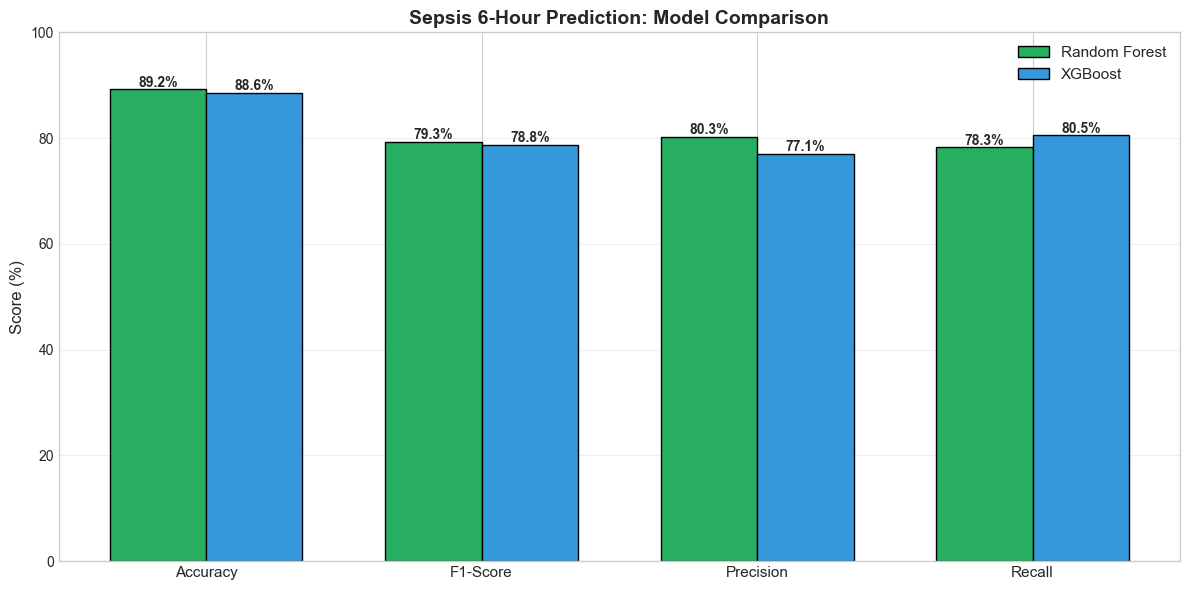

In [17]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_list = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
rf_vals = [rf_metrics[m] for m in metrics_list]
xgb_vals = [xgb_metrics[m] for m in metrics_list] if XGB_AVAILABLE else [0]*4

x = np.arange(len(metrics_list))
width = 0.35

bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest', 
               color='#27ae60', edgecolor='black')
if XGB_AVAILABLE:
    bars2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost', 
                   color='#3498db', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
if XGB_AVAILABLE:
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Sepsis 6-Hour Prediction: Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model/model_comparison_6h.png', dpi=150)
plt.show()

## 12. ROC Curves

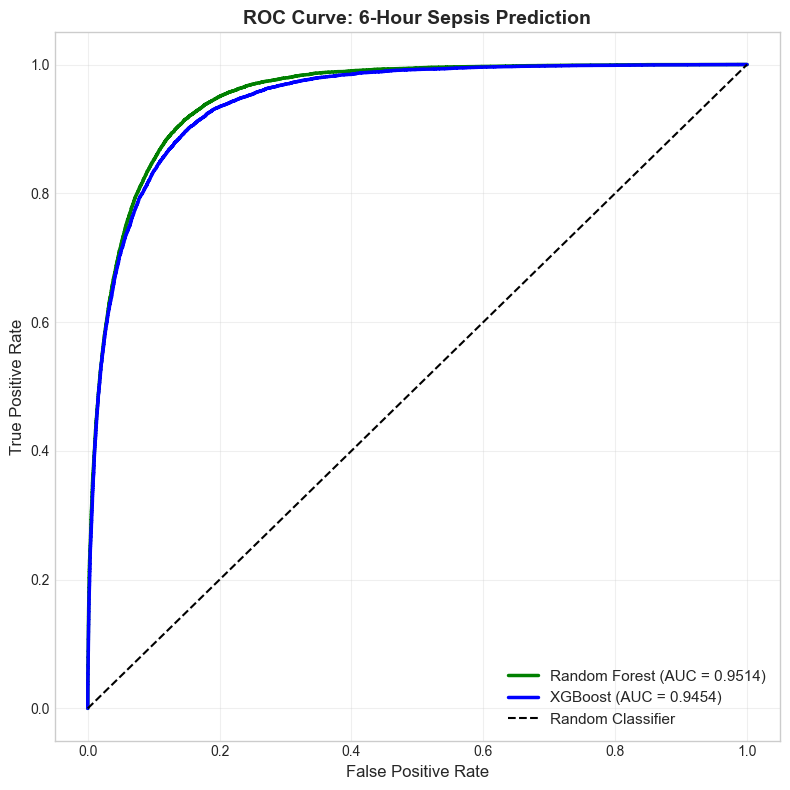

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
ax.plot(rf_fpr, rf_tpr, 'g-', linewidth=2.5, 
        label=f'Random Forest (AUC = {rf_metrics["ROC-AUC"]:.4f})')

if XGB_AVAILABLE:
    xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
    ax.plot(xgb_fpr, xgb_tpr, 'b-', linewidth=2.5, 
            label=f'XGBoost (AUC = {xgb_metrics["ROC-AUC"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve: 6-Hour Sepsis Prediction', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model/roc_curve_6h.png', dpi=150)
plt.show()

## 13. Confusion Matrices

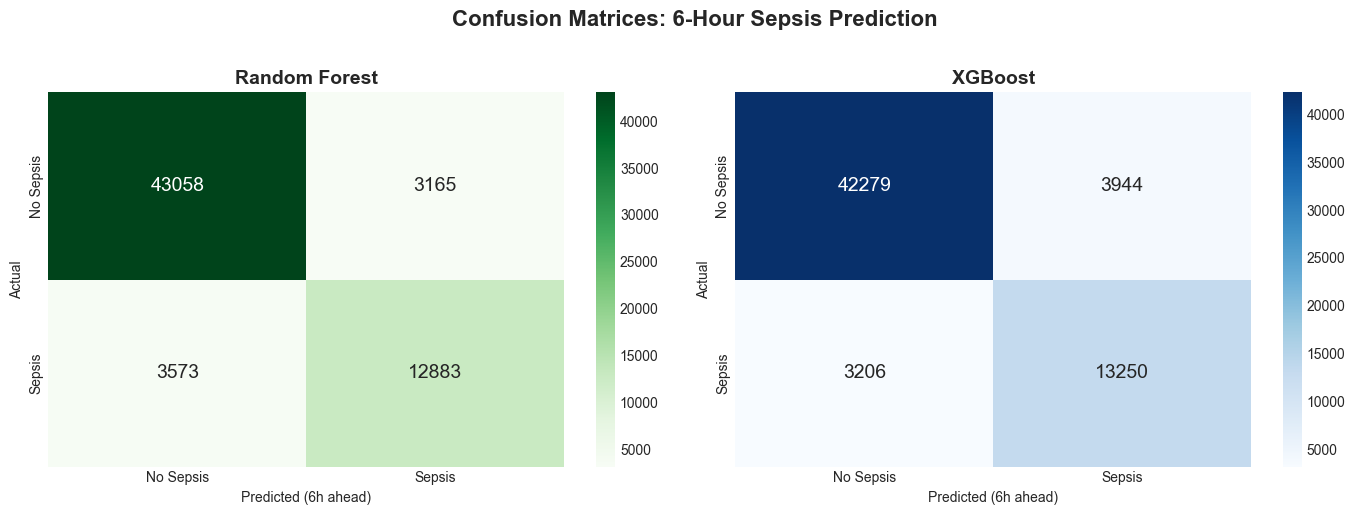

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Sepsis', 'Sepsis'], 
            yticklabels=['No Sepsis', 'Sepsis'],
            annot_kws={'size': 14})
axes[0].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted (6h ahead)')
axes[0].set_ylabel('Actual')

if XGB_AVAILABLE:
    xgb_cm = confusion_matrix(y_test, xgb_pred)
    sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=['No Sepsis', 'Sepsis'], 
                yticklabels=['No Sepsis', 'Sepsis'],
                annot_kws={'size': 14})
    axes[1].set_title('XGBoost', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted (6h ahead)')
    axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrices: 6-Hour Sepsis Prediction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model/confusion_matrix_6h.png', dpi=150)
plt.show()

## 14. Feature Importance

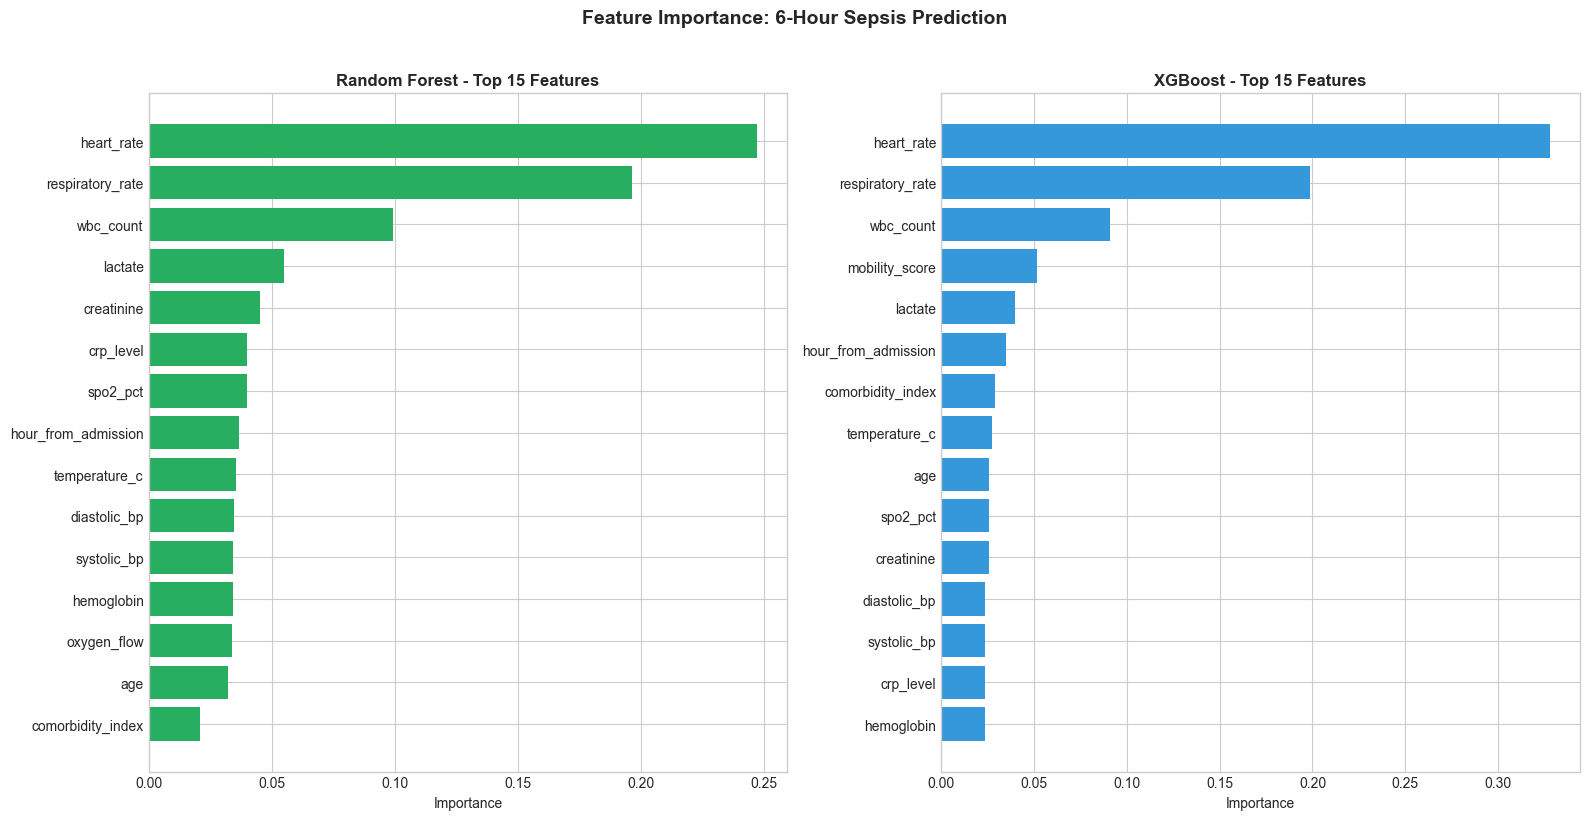

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# RF feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols, 
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='#27ae60')
axes[0].set_title('Random Forest - Top 15 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost feature importance
if XGB_AVAILABLE:
    xgb_importance = pd.DataFrame({
        'Feature': feature_cols, 
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)
    
    axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='#3498db')
    axes[1].set_title('XGBoost - Top 15 Features', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance: 6-Hour Sepsis Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model/feature_importance_6h.png', dpi=150)
plt.show()

## 15. Save Models

In [20]:
import os
os.makedirs('model', exist_ok=True)

# Save Random Forest
joblib.dump(rf_model, 'model/sepsis_rf_model.pkl')
joblib.dump(imputer, 'model/imputer.pkl')
with open('model/sepsis_optimal_threshold.txt', 'w') as f:
    f.write(str(best_thresh_rf))
with open('model/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_cols))
print("💾 Random Forest model saved!")

if XGB_AVAILABLE:
    joblib.dump(xgb_model, 'model/sepsis_xgb_model.pkl')
    with open('model/xgb_threshold.txt', 'w') as f:
        f.write(str(best_thresh_xgb))
    print("💾 XGBoost model saved!")

💾 Random Forest model saved!
💾 XGBoost model saved!


## 16. 📋 Final Summary

In [21]:
print("\n" + "="*75)
print("     🏥 SEPSIS 6-HOUR EARLY WARNING SYSTEM - SUMMARY")
print("="*75)

print(f"""
📊 DATASET:
   • Total records: {len(df):,}
   • Training:      {len(X_train):,}
   • Validation:    {len(X_val):,}
   • Test:          {len(X_test):,}
   • Features:      {len(feature_cols)}

🎯 TASK:
   • Target: Predict sepsis onset 6 hours ahead
   • Using SIRS criteria (Temp, HR, RR, WBC)

🌲 RANDOM FOREST:
   • Accuracy:   {rf_metrics['Accuracy']:.2f}%
   • F1-Score:   {rf_metrics['F1-Score']:.2f}%
   • Precision:  {rf_metrics['Precision']:.2f}%
   • Recall:     {rf_metrics['Recall']:.2f}%
   • ROC-AUC:    {rf_metrics['ROC-AUC']:.4f}
   • Threshold:  {best_thresh_rf:.2f}
""")

if XGB_AVAILABLE:
    print(f"""🚀 XGBOOST:
   • Accuracy:   {xgb_metrics['Accuracy']:.2f}%
   • F1-Score:   {xgb_metrics['F1-Score']:.2f}%
   • Precision:  {xgb_metrics['Precision']:.2f}%
   • Recall:     {xgb_metrics['Recall']:.2f}%
   • ROC-AUC:    {xgb_metrics['ROC-AUC']:.4f}
   • Threshold:  {best_thresh_xgb:.2f}
""")

# Winner determination
if XGB_AVAILABLE:
    if xgb_metrics['ROC-AUC'] > rf_metrics['ROC-AUC']:
        print("🏆 BEST MODEL: XGBoost (Higher ROC-AUC)")
    elif rf_metrics['ROC-AUC'] > xgb_metrics['ROC-AUC']:
        print("🏆 BEST MODEL: Random Forest (Higher ROC-AUC)")
    else:
        print("🏆 RESULT: Both models perform similarly")

print("\n" + "="*75)
print("       ✅ 6-HOUR SEPSIS PREDICTION MODEL TRAINING COMPLETE!")
print("="*75)


     🏥 SEPSIS 6-HOUR EARLY WARNING SYSTEM - SUMMARY

📊 DATASET:
   • Total records: 417,860
   • Training:      292,669
   • Validation:    62,512
   • Test:          62,679
   • Features:      17

🎯 TASK:
   • Target: Predict sepsis onset 6 hours ahead
   • Using SIRS criteria (Temp, HR, RR, WBC)

🌲 RANDOM FOREST:
   • Accuracy:   89.25%
   • F1-Score:   79.27%
   • Precision:  80.28%
   • Recall:     78.29%
   • ROC-AUC:    0.9514
   • Threshold:  0.50

🚀 XGBOOST:
   • Accuracy:   88.59%
   • F1-Score:   78.75%
   • Precision:  77.06%
   • Recall:     80.52%
   • ROC-AUC:    0.9454
   • Threshold:  0.63

🏆 BEST MODEL: Random Forest (Higher ROC-AUC)

       ✅ 6-HOUR SEPSIS PREDICTION MODEL TRAINING COMPLETE!
